In [1]:
!rm -f dndmsc26spring_hw1_tester.py 
!curl -O http://nipg12.inf.elte.hu/~vavsaai@nipg.lab/dndmsc26spring/files/dndmsc26spring_hw1_tester.py

import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from dndmsc26spring_hw1_tester import Tester

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 14757  100 147 0    0     0      0      0 --:--:-- --:--:-- --:--:--     057    0     0   435k      0 --:--:-- --:--:-- --:--:--  436k


In [2]:
tester = Tester()
content = tester.get_dataset_content()

print("Number of characters in dataset:", len(content))
print(content[:500])

Number of characters in dataset: 27418
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0;0;18;0;1;1;4;4;5;0;4;;2;2;0;0;1;1;1;0;0;1;1;4;3;4;1;1;3;6;14;15;15
0;0;17;0;1;0;1;1;5;3;4;1;1;2;0;1;0;1;1;1;0;0;1;5;3;3;1;1;3;4;6;6;7
0;0;15;0;0;0;1;1;5;;3;;1;2;3;0;1;0;1;0;0;0;1;4;3;2;2;3;3;10;7;7;8
0;0;15;0;1;0;4;2;1;4;0;;1;3;0;1;0;0;0;0;0;0;0;3;2;2;1;1;5;2;15;15;15
0


A. Loading the Dataset

In [3]:
lines = content.splitlines()

data_lines = lines[1:]

data = []

for line in data_lines:
    values = line.split(';')
    row = []

    for i, val in enumerate(values):
        if val == "":
            if i in [8, 9, 19]:
                row.append(np.nan)
            else:
                row.append(np.nan)
        else:
            row. append(np.float32(val))

    data.append(row)

dataset_noisy = np.array(data, dtype=np.float32)

tester.test('dataset_load', dataset_noisy)

Tester: Dataset loading OK


## B. Handling the Missing Data

In [4]:
nan_columns = [8, 9, 11]

indicators = []

for col in nan_columns:
    indicator = (~np.isnan(dataset_noisy[:, col])).astype(np.float32)
    indicators.append(indicator.reshape(-1, 1))

indicator_matrix = np.hstack(indicators)

dataset = np.hstack([dataset_noisy, indicator_matrix])

dataset = np.nan_to_num(dataset, nan=0.0)

tester.test('dataset_fill_missing', dataset)

Tester: Dataset fill missing OK


## C: Splitting into training, validation, and test sets

In [5]:
np.random.seed(42)
shuffled_indices = np.random.permutation(dataset.shape[0])
dataset_shuffled = dataset[shuffled_indices]

n = dataset.shape[0]
train_end = int(0.5 * n)
val_end  =  int(0.75 * n)

dataset_split_train = dataset_shuffled[:train_end]
dataset_split_val = dataset_shuffled[train_end:val_end]
dataset_split_test = dataset_shuffled[val_end:]

tester.test('dataset_split', dataset_split_train, dataset_split_val, dataset_split_test)

Tester: Dataset split OK


## D: Creating data iterators for the regression task

In [6]:
class StudentDataset(Dataset):
    def __init__(self, data_array):
        self.X = np.delete(data_array, 32, axis=1)
        self.y = data_array[:, 32].reshape(-1, 1)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        x = torch.tensor(self.X[index], dtype=torch.float32)
        y = torch.tensor(self.y[index], dtype=torch.float32)
        return x, y
    
train_dataset = StudentDataset(dataset_split_train)
val_dataset = StudentDataset(dataset_split_val)
test_dataset = StudentDataset(dataset_split_test)

batchsize = 32

dataloader_reg_train = DataLoader(train_dataset, batch_size=batchsize, shuffle=True)
dataloader_reg_val = DataLoader(val_dataset, batch_size=batchsize, shuffle=True)
dataloader_reg_test = DataLoader(test_dataset, batch_size=batchsize, shuffle=False)

tester.test('reg_iter', dataloader_reg_train, dataloader_reg_val, dataloader_reg_test)



Tester: Dataset iterators for regression task OK


## E: Defining the regression neural network

In [7]:
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(35, 25)
        self.fc2 = nn.Linear(25, 25)
        self.fc3 = nn.Linear(25, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
reg_model = RegressionModel()

tester.test('reg_model_architecture', reg_model)

Tester: Regression model architecture OK


## F: Training the network for the regression task

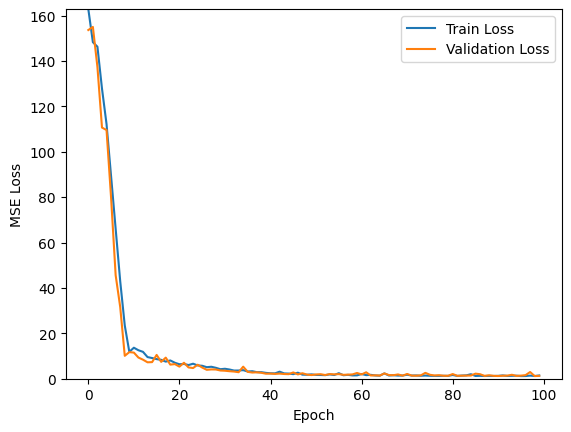

Pred: 11.72, True: 12.00
Pred: 6.15, True: 3.00
Pred: 15.78, True: 15.00
Pred: 8.45, True: 8.00
Pred: 8.49, True: 9.00
Tester: Regression model learning OK


In [8]:
criterion = nn.MSELoss()
optimiser = torch.optim.Adam(reg_model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    reg_model.train()
    train_loss = 0.0 

    for X, y in dataloader_reg_train:
        optimiser.zero_grad()
        outputs = reg_model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimiser.step()
        train_loss += loss.item()

    train_loss /= len(dataloader_reg_train)

    reg_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in dataloader_reg_val:
            outputs = reg_model(X)
            loss = criterion(outputs, y)
            val_loss += loss.item() 

    val_loss /= len(dataloader_reg_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)


plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.ylim(0, max(train_losses))
plt.show()


reg_model.eval()
test_loss = 0.0
with torch.no_grad():
    for X, y in dataloader_reg_test:
        outputs = reg_model(X)
        loss = criterion(outputs, y)
        test_loss += loss.item()

test_mse = test_loss / len(dataloader_reg_test)

for X, y in dataloader_reg_test:
    preds = reg_model(X)
    for i in range(5):
        print(f"Pred: {preds[i].item():.2f}, True: {y[i].item():.2f}")
    break

tester.test('reg_model_learning', test_mse)

## G: Creating data iterators for the classification task

In [9]:
class ClassificationDataset():
    def __init__(self, data_array):
        self.X = np.delete(data_array, [30, 31, 32], axis=1)

        g1 = data_array[:, 30]
        g2 = data_array[:, 31]
        g3 = data_array[:, 32]

        self.y = []

        for i in range(len(data_array)):
            grades = [g1[i], g2[i], g3[i]]

            if sum(g < 11 for g in grades) >= 2:
                self.y.append(0)

            elif np.mean(grades) < 14:
                self.y.append(1)

            else:
                self.y.append(2)

        self.y = np.array(self.y, dtype=np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.int64)
        return x, y

batch_size = 32

dataloader_cl_train = DataLoader(ClassificationDataset(dataset_split_train), batch_size=batch_size, shuffle=True)
dataloader_cl_val = DataLoader(ClassificationDataset(dataset_split_val), batch_size=batch_size, shuffle=True)
dataloader_cl_test = DataLoader(ClassificationDataset(dataset_split_test), batch_size=batch_size, shuffle=False)

tester.test('cl_iter', dataloader_cl_train, dataloader_cl_val, dataloader_cl_test)

Tester: Dataset iterators for classification task OK


## H: Defining the classification neural network

In [10]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(33, 30)
        self.fc2 = nn.Linear(30, 20)
        self.fc3 = nn.Linear(20, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # no softmax here!
        return x

cl_model = ClassificationModel()

tester.test('cl_model_architecture', cl_model)

Tester: Classification model architecture OK


## I: Training the network for the multi-class classification task

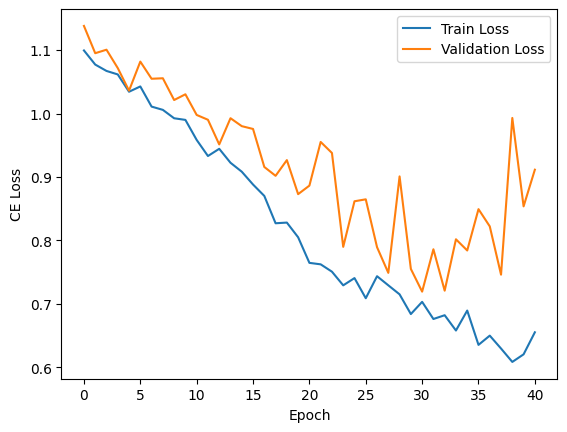

Pred: 0, True: 1
Pred: 0, True: 0
Pred: 2, True: 2
Pred: 0, True: 0
Pred: 0, True: 0


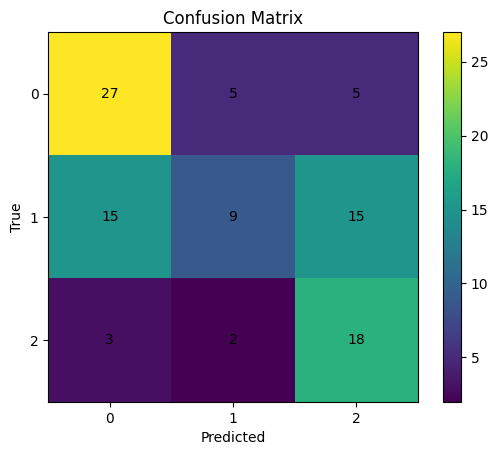

Tester: Classification model learning OK


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cl_model.parameters(), lr=0.001)

num_epochs = 200
patience = 10

best_val_loss = float('inf')
patience_counter = 0
best_model_state = copy.deepcopy(cl_model.state_dict())

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    cl_model.train()
    train_loss = 0.0

    for X, y in dataloader_cl_train:
        optimizer.zero_grad()
        outputs = cl_model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(dataloader_cl_train)

    cl_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in dataloader_cl_val:
            outputs = cl_model(X)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    val_loss /= len(dataloader_cl_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(cl_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        break

cl_model.load_state_dict(best_model_state)


plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("CE Loss")
plt.show()


cl_model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in dataloader_cl_test:
        outputs = cl_model(X)
        loss = criterion(outputs, y)
        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

test_ce = test_loss / len(dataloader_cl_test)
test_acc = correct / total

for X, y in dataloader_cl_test:
    outputs = cl_model(X)
    preds = torch.argmax(outputs, dim=1)
    for i in range(5):
        print(f"Pred: {preds[i].item()}, True: {y[i].item()}")
    break

conf_matrix = np.zeros((3, 3), dtype=int)

for t, p in zip(all_labels, all_preds):
    conf_matrix[t, p] += 1

plt.figure()
plt.imshow(conf_matrix)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1,2])
plt.yticks([0,1,2])

for i in range(3):
    for j in range(3):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center')

plt.colorbar()
plt.show()


tester.test('cl_model_learning', test_ce, test_acc)